# Data exploration: free-speed simulations

Unconstrained forward-velocity simulations (`sipp_generic_runmad_smoothsphere_bhargavaact{i}_0.mat`) -- speed is an emergent outcome of the optimization, not an imposed target. The optimizer's speed guess is bounded at 1.8 m/s (`run_free_speed.m`), so trials that land at that bound are speed-limited rather than freely converged and are excluded below.

In [1]:
import sys; sys.path.insert(0, 'evaluation')  # analysis modules moved here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import gait_loading as gl
import gait_metrics as gm
from gait_loading import get_reference_data

SPEED_BOUND_MIN = 0.2
SPEED_BOUND = 1.8  # v_guess upper bound in run_free_speed.m -- trials at/above this hit the bound, not a free optimum

df = gl.load_free_speed_results()
df['status'] = df['info_'].apply(lambda x: x.get('status', np.nan))
print(f'Loaded {len(df)} free-speed trials')
df[['i', 'speed', 'converged', 'status', 'dur','msk_model']]

Loaded 59 free-speed trials


,i,speed,converged,status,dur,msk_model
0,10,1.800011,1,0,0.373211,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
1,11,1.208207,1,0,0.523625,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
2,1,1.800017,1,0,0.382165,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
3,2,1.201960,1,0,0.519880,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
4,3,1.203698,1,0,0.520939,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
5,4,1.200376,1,0,0.524649,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
6,5,1.218349,0,-2,0.524406,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
7,6,1.181282,1,0,0.527640,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
8,7,1.194089,1,0,0.529715,sipp_generic_runmad_smoothsphere_30bwa_bhargav...
9,8,1.199726,1,0,0.522902,sipp_generic_runmad_smoothsphere_30bwa_bhargav...


## 1: Convergence & speed-bound filtering

In [2]:
df['hit_speed_bound'] = (df['speed'] >= SPEED_BOUND - 1e-3) | (df['speed'] <= SPEED_BOUND_MIN + 1e-3)
print('Converged:', df['converged'].astype(bool).sum(), '/', len(df))
print('Hit speed bound:', df['hit_speed_bound'].sum(), '/', len(df))
print(df[['i', 'converged', 'speed', 'hit_speed_bound', 'status']].to_string(index=False))

df = df[(df['converged'] == True) & (~df['hit_speed_bound'])].copy()
print(f'\n{len(df)} trials remain after filtering (converged, below speed bound).')

Converged: 52 / 59
Hit speed bound: 26 / 59
 i  converged    speed  hit_speed_bound  status
10          1 1.800011             True       0
11          1 1.208207            False       0
 1          1 1.800017             True       0
 2          1 1.201960            False       0
 3          1 1.203698            False       0
 4          1 1.200376            False       0
 5          0 1.218349            False      -2
 6          1 1.181282            False       0
 7          1 1.194089            False       0
 8          1 1.199726            False       0
 9          1 1.193614            False       0
10          1 1.189456            False       0
 1          1 1.202711            False       0
 2          1 1.244062            False       0
 3          1 1.198921            False       0
 4          1 1.800028             True       0
 5          1 1.234064            False       0
 6          1 1.206309            False       0
 7          1 1.800023             True     

## 2: Emergent speed distribution

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_49473/930619827.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


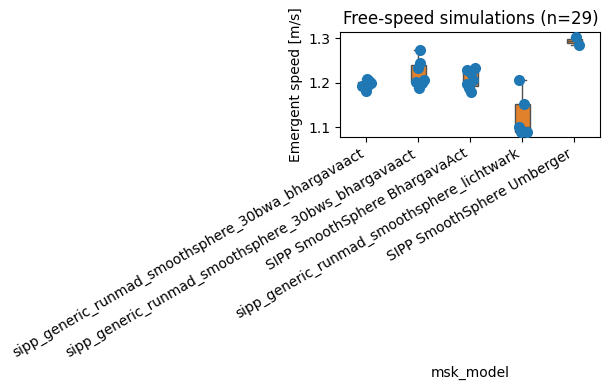

count    29.000000
mean      1.200454
std       0.048566
min       1.089986
25%       1.189456
50%       1.201960
75%       1.221587
max       1.302313
Name: speed, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
df = df[df['msk_model'] != 'SIPP SmoothSphere no metcost']
sns.stripplot(x=df['msk_model'], y=df['speed'], ax=ax, size=8)
sns.boxplot( y=df['speed'], ax=ax, width=0.3, x=df['msk_model'])
ax.set_ylabel('Emergent speed [m/s]')
# rotate x-tick labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title(f'Free-speed simulations (n={len(df)})')
plt.tight_layout()
plt.show()

print(df['speed'].describe())

## 3: Metabolic cost vs. emergent speed

All metabolic-model estimates were computed for every trial (the model itself only picked Bhargava-activation-dependent as the objective); compare them at each subject's own emergent speed.

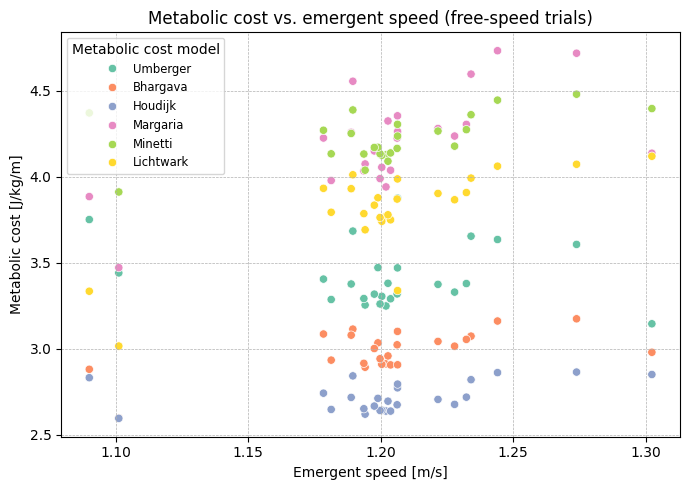

In [26]:
metcost_cols = ['metabolicCostUmberger', 'metabolicCostBhargava', 'metabolicCostHoudijk',
                'metabolicCostMargaria', 'metabolicCostMinetti', 'metabolicCostLichtwark']
model_label_map = {
    'metabolicCostUmberger': 'Umberger', 'metabolicCostBhargava': 'Bhargava',
    'metabolicCostHoudijk': 'Houdijk', 'metabolicCostMargaria': 'Margaria',
    'metabolicCostMinetti': 'Minetti', 'metabolicCostLichtwark': 'Lichtwark',
}
df_melted = df.melt(id_vars=['i', 'speed'], value_vars=metcost_cols,
                     var_name='metcost_model', value_name='metcost_value')
df_melted['metcost_model'] = df_melted['metcost_model'].map(model_label_map)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_melted, x='speed', y='metcost_value', hue='metcost_model', palette='Set2', ax=ax)
ax.set_xlabel('Emergent speed [m/s]')
ax.set_ylabel('Metabolic cost [J/kg/m]')
ax.set_title('Metabolic cost vs. emergent speed (free-speed trials)')
ax.legend(title='Metabolic cost model', fontsize='small')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## 4: Cadence vs. speed

Compare cadence against literature walk/run cadence-speed relations.

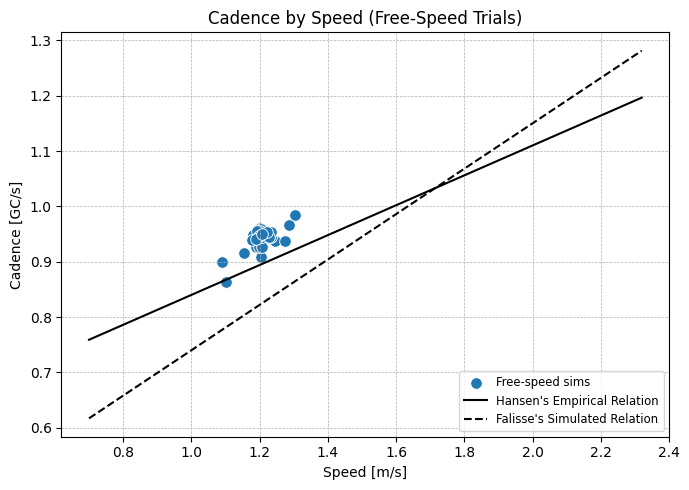

In [6]:
df['cadence'] = 1 / (df['dur'] * 2)
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x='speed', y='cadence', data=df, s=70, ax=ax, label='Free-speed sims')
ax.plot(np.arange(0.7, 2.33, 0.01), np.arange(0.7, 2.33, 0.01) * 0.27 + 0.57,
        label="Hansen's Empirical Relation", color='black')
ax.plot(np.arange(0.7, 2.33, 0.01), np.arange(0.7, 2.33, 0.01) * 0.41 + 0.33,
        linestyle='--', label="Falisse's Simulated Relation", color='black')
ax.set_xlabel('Speed [m/s]')
ax.set_ylabel('Cadence [GC/s]')
ax.set_title('Cadence by Speed (Free-Speed Trials)')
ax.legend(loc='lower right', fontsize='small')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## 5: Joint angles & GRF vs. reference data at matched speed

Each trial is compared to the experimental reference closest to its own emergent speed, using `gm.trial_curves` / `gm.align_and_maes` / `gm.reference_curves` (shift-aligned MAE, same as the speed-sweep notebooks).

In [28]:
rows = []
for _, row in df.iterrows():
    ref_data = get_reference_data(row['speed'])
    ref_angles, ref_angles_std, ref_grf, ref_grf_std = gm.reference_curves(ref_data)
    sim_angles, sim_grf = gm.trial_curves(row)
    angle_mae, grf_mae = gm.align_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
    rows.append({'i': row['i'], 'speed': row['speed'],
                 'Kinematic MAE (deg)': angle_mae, 'GRF MAE (BW)': grf_mae})

error_df = pd.DataFrame(rows)
print(error_df.to_string(index=False))
print('\nMean:')
print(error_df[['Kinematic MAE (deg)', 'GRF MAE (BW)']].mean())

 i    speed  Kinematic MAE (deg)  GRF MAE (BW)
 2 1.201960             2.731450      0.025637
 3 1.203698             2.586276      0.028342
 4 1.200376             2.571371      0.030194
 6 1.181282             2.592628      0.025916
 7 1.194089             2.716448      0.032267
 8 1.199726             2.719489      0.024726
 9 1.193614             2.553051      0.027224
10 1.189456             2.767995      0.030971
 1 1.202711             3.049810      0.027599
 2 1.244062             2.701459      0.028153
 3 1.198921             3.173828      0.032364
 5 1.234064             2.651892      0.027585
 6 1.206309             3.159784      0.032983
 9 1.273886                  NaN           NaN
10 1.178364             2.872531      0.024874
11 1.232303             2.680997      0.028315
 1 1.206172             2.781903      0.030546
 2 1.227856             2.719464      0.028684
 3 1.221587             2.738750      0.027871
 5 1.197560             2.710268      0.030967
 8 1.188828  

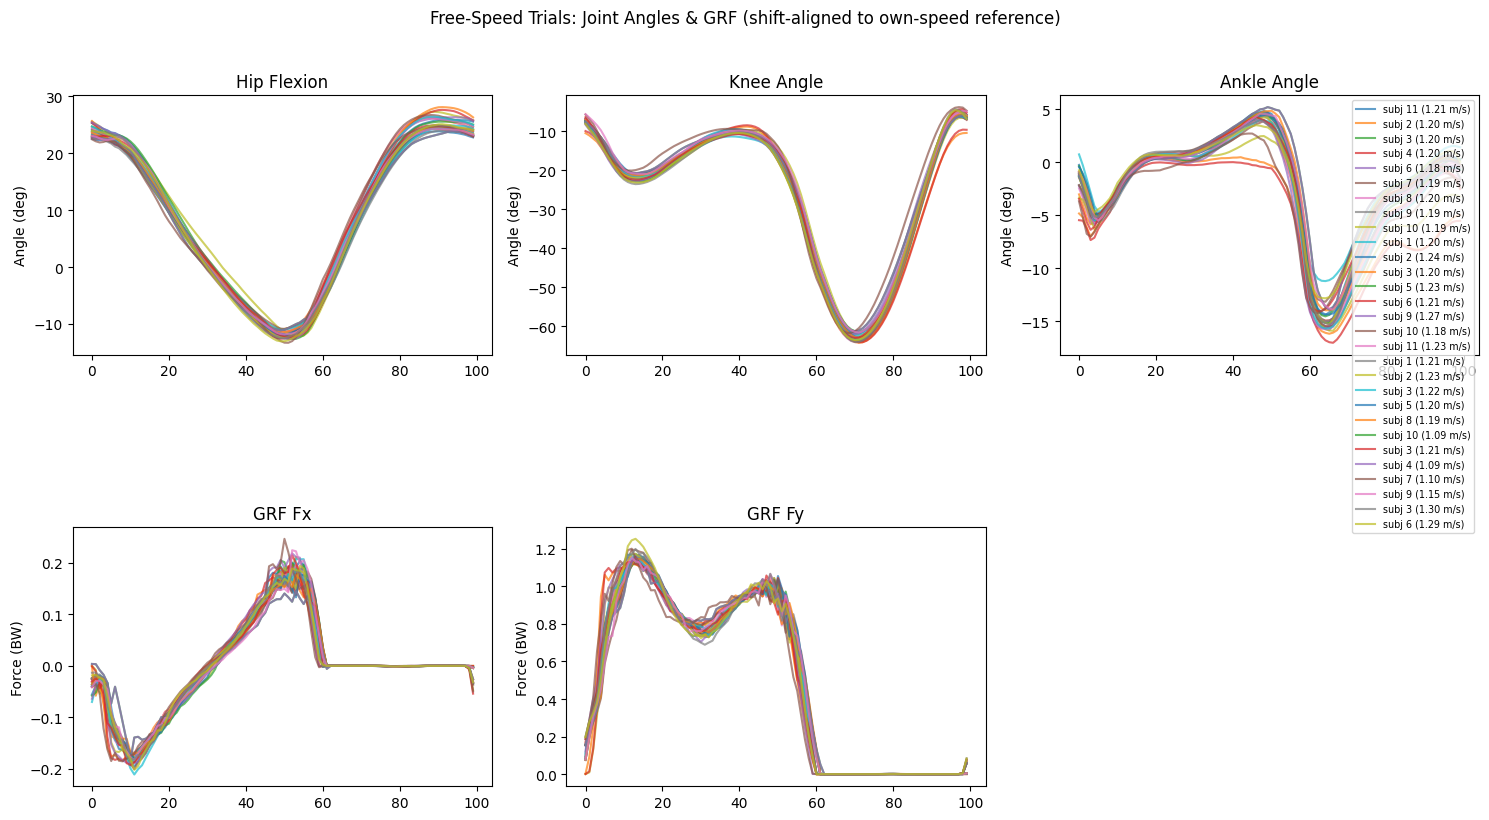

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
joint_names = ['hip_flexion', 'knee_angle', 'ankle_angle']
grf_names = ['Fx', 'Fy']
cmap = plt.get_cmap('tab10')
model_order = sorted(df['msk_model'].dropna().unique())
model_to_color = {m: cmap(i % cmap.N) for i, m in enumerate(model_order)}
seen_models = set()
for idx, (_, row) in enumerate(df.iterrows()):
    sim_angles, sim_grf = gm.trial_curves(row)
    ref_data = get_reference_data(row['speed'])
    ref_angles, ref_angles_std, ref_grf, ref_grf_std = gm.reference_curves(ref_data)

    best_shift, min_mae = 0, np.inf
    if ref_angles is not None:
        for shift in range(100):
            mae = np.nanmean(np.abs(np.roll(sim_angles, shift, axis=0) - ref_angles))
            if mae < min_mae:
                min_mae, best_shift = mae, shift
    sim_angles = np.roll(sim_angles, best_shift, axis=0)
    sim_grf = np.roll(sim_grf, best_shift, axis=0)
    color = cmap(idx % 10)

    for j in range(3):
        axes[0, j].plot(sim_angles[:, j], color=color, alpha=0.7,
                        label=f"subj {row['i']} ({row['speed']:.2f} m/s)")
    for j in range(2):
        axes[1, j].plot(sim_grf[:, j], color=color, alpha=0.7)

for j, joint in enumerate(joint_names):
    ax = axes[0, j]
    ax.set_title(joint.replace('_', ' ').title())
    ax.set_ylabel('Angle (deg)')
for j, grf_name in enumerate(grf_names):
    ax = axes[1, j]
    ax.set_title(f'GRF {grf_name}')
    ax.set_ylabel('Force (BW)')
axes[0, 2].legend(fontsize='x-small', loc='upper right')
axes[1, 2].axis('off')
plt.suptitle('Free-Speed Trials: Joint Angles & GRF (shift-aligned to own-speed reference)', y=1.02)
plt.tight_layout()
plt.show()

## 6: Free-speed PredSim reps (workstation)

A separate free-speed source: PredSim itself (not the BioMAC/OpenSim pipeline above), run directly on the lab workstation (`~/phd/predsim/results/free_speed_noisy`), one subject (Falisse et al. 2022 model), forward velocity bounded in [0.5, 2] m/s rather than imposed, 10 reps with a noisy initial guess (`rng(k)`-perturbed kinematic guess + `v_guess ~ U(0.5,2)`) so each rep can in principle land in a different local optimum. The cost is per-unit-distance, so the optimizer is free to pick whatever speed minimizes cost of transport.

The original `free_speed` run set (launched 2026-08-13, clean guesses) never produced results -- it never obtained a MATLAB license seat before the launcher gave up (missing `LM_PROJECT=iwse`; see AGENTS.md). `free_speed_noisy` was relaunched 2026-08-14 with the fix and completed 2026-08-16 with all 10/10 reps converged (`Solve_Succeeded`).

  rep    speed      dur  cadence  metabolicCost
rep09 0.681763 1.731273 0.288805       5.500996
rep02 0.724953 1.531962 0.326379       5.149602
rep04 0.725870 1.519427 0.329071       5.150102
rep05 0.726699 1.516905 0.329619       5.148234
rep01 0.730168 1.531190 0.326543       5.124264
rep06 0.730255 1.531082 0.326566       5.123680
rep03 0.730256 1.530502 0.326690       5.124282
rep10 0.730279 1.531027 0.326578       5.124169
rep07 0.730296 1.530953 0.326594       5.123825
rep08 1.004343 1.245195 0.401543       7.221733


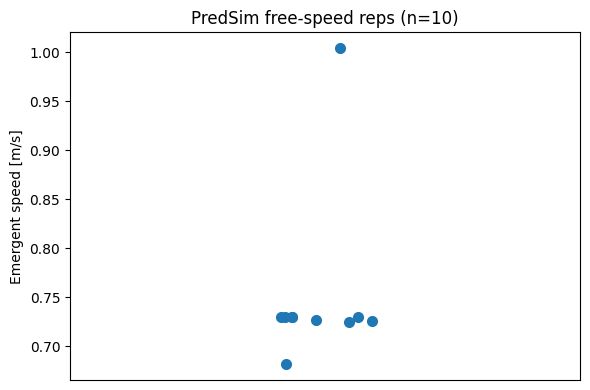

In [30]:
predsim_free = gl.load_free_speed_predsim()
predsim_free['cadence'] = 1 / (predsim_free['dur'] * 2)
print(predsim_free[['rep', 'speed', 'dur', 'cadence', 'metabolicCost']].to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
sns.stripplot(x=[0] * len(predsim_free), y=predsim_free['speed'], ax=ax, size=8)
ax.set_xticks([])
ax.set_ylabel('Emergent speed [m/s]')
ax.set_title(f'PredSim free-speed reps (n={len(predsim_free)})')
plt.tight_layout()
plt.show()

9 of the 10 reps converge to essentially the same emergent speed (~0.73 m/s) regardless of `v_guess` spanning almost the whole [0.5, 2] m/s bound range -- the noisy initial guess is barely perturbing the basin of attraction. Only rep08 (and weakly rep09) finds a different optimum (~1.0 m/s). That is a narrower emergent-speed spread than the BioMAC free-speed sims above (which cluster around 1.2 m/s) -- the two pipelines are not optimizing the same cost (PredSim's per-distance objective vs. BioMAC's per-time one), so the different optimal speeds are expected, but the near-total lack of multimodality here is worth a closer look before trusting `free_speed_noisy` as a real multi-optimum sample.

In [31]:
rows = []
for _, row in predsim_free.iterrows():
    ref_data = get_reference_data(row['speed'])
    ref_angles, ref_angles_std, ref_grf, ref_grf_std = gm.reference_curves(ref_data)
    sim_angles, sim_grf = gm.trial_curves(row)
    angle_mae, grf_mae = gm.align_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
    rows.append({'rep': row['rep'], 'speed': row['speed'],
                 'Kinematic MAE (deg)': angle_mae, 'GRF MAE (BW)': grf_mae})

predsim_error_df = pd.DataFrame(rows)
print(predsim_error_df.to_string(index=False))
print('\nMean:')
print(predsim_error_df[['Kinematic MAE (deg)', 'GRF MAE (BW)']].mean())

  rep    speed  Kinematic MAE (deg)  GRF MAE (BW)
rep09 0.681763                  NaN           NaN
rep02 0.724953                  NaN           NaN
rep04 0.725870                  NaN           NaN
rep05 0.726699                  NaN           NaN
rep01 0.730168                  NaN           NaN
rep06 0.730255                  NaN           NaN
rep03 0.730256                  NaN           NaN
rep10 0.730279                  NaN           NaN
rep07 0.730296                  NaN           NaN
rep08 1.004343             6.800931      0.058766

Mean:
Kinematic MAE (deg)    6.800931
GRF MAE (BW)           0.058766
dtype: float64


Most reps show NaN here: `get_reference_data` only matches within +-0.05 m/s of its fixed speed grid (0.6, 0.8, ..., 1.6), and 9/10 reps landed at ~0.70-0.73 m/s -- between grid points. The benchmark table in section 7 uses a looser nearest-anchor snap (`load_reference_subject_curves`, +-0.1 m/s) and does score every rep; treat those numbers as nearest-neighbor comparisons, not matched-speed ones, for this source.

## 7: Benchmark against other free-speed generative models

Compare our free-speed predictive simulations against the other unconstrained-generation sets in `benchmarks/free/` -- GaitEncoder (Magruder et al. 2026, kinematics-only VAE, sampled from both its healthy-subject latent cloud and its full N(0,I) prior), Generative GaitNet (Park et al. 2022, muscle-actuated DRL; `free_gait` draws stride/cadence conditions with a healthy anatomy, `free_all` draws every parameter from the model's own distribution), and GaitDynamics (Tan et al. 2025, diffusion model, unconditional sampling). None of these had a speed imposed -- `speed_achieved` is the emergent outcome, same as our own free-speed sims.

Each trial is assigned to its nearest experimental reference anchor (walking: 0.6-1.6 m/s in 0.2 steps; running: the Fukuchi 2.53/3.53/4.53 m/s trials), then scored two ways against the individual reference *subjects* at that anchor (`gl.load_reference_subject_curves`):

- **MAE** -- shift-aligned mean absolute error against the reference mean curve (`gm.align_and_maes`, as in section 5).
- **Wasserstein W1** -- 1-Wasserstein distance between the pooled per-channel value distributions (all phase points x all trials vs. all phase points x all reference subjects). This needs no phase alignment: circularly shifting a cycle permutes *when* a value occurs, not the set of values themselves, so W1 sees whether the right *range* of angles/forces is produced without caring where in the cycle they land.

GaitEncoder carries no GRF (kinematics-only), so its GRF MAE/W1 are NaN by construction, not a modeling failure.

In [32]:
import gait_distributions as gd

free_sources = {
    'Ours (SIPP BhargavaAct)': (df, 'speed'),
    'PredSim (workstation)': (predsim_free, 'speed'),
    'GaitEncoder (healthy)': (gl.load_genbench_free('gaitencoder'), 'speed_achieved'),
    'GaitEncoder (prior)': (gl.load_genbench_free('gaitencoder_prior'), 'speed_achieved'),
    'GaitNet (free gait)': (gl.load_genbench_free('gaitnet'), 'speed_achieved'),
    #'GaitNet (free all)': (gl.load_genbench_free('gaitnet_all'), 'speed_achieved'),
    'GaitDynamics (free)': (gl.load_genbench_free('gaitdynamics'), 'speed_achieved'),
}
for label, (rows, speed_col) in free_sources.items():
    print(f'{label}: {len(rows)} trials, speed {rows[speed_col].min():.2f}-{rows[speed_col].max():.2f} m/s')

Ours (SIPP BhargavaAct): 25 trials, speed 1.09-1.30 m/s
PredSim (workstation): 10 trials, speed 0.68-1.00 m/s
GaitEncoder (healthy): 1000 trials, speed 0.81-1.77 m/s
GaitEncoder (prior): 1000 trials, speed 0.09-1.77 m/s
GaitNet (free gait): 180 trials, speed 0.75-1.55 m/s
GaitDynamics (free): 130 trials, speed 0.72-3.37 m/s


In [33]:
ANCHOR_SPEEDS = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 2.53, 3.53, 4.53]

def _nearest_anchor(speed):
    return min(ANCHOR_SPEEDS, key=lambda a: abs(a - speed))

def _pooled_w1(model_pool, ref_pool, n_channels):
    """Per-channel W1 between pooled model and reference samples; NaN where either side is empty."""
    out = []
    for c in range(n_channels):
        a = model_pool[:, c]
        b = ref_pool[:, c]
        a, b = a[~np.isnan(a)], b[~np.isnan(b)]
        out.append(gd.scipy_w1(a, b) if len(a) and len(b) else np.nan)
    return out

def evaluate_free_source(rows, label, speed_col):
    rows = rows.copy()
    rows['_anchor'] = rows[speed_col].astype(float).apply(_nearest_anchor)
    results = []
    for anchor, group in rows.groupby('_anchor'):
        ref_data = get_reference_data(anchor)
        ref_angles, _, ref_grf, _ = gm.reference_curves(ref_data)
        ref_subjects = gl.load_reference_subject_curves(anchor)
        if ref_angles is None or not ref_subjects:
            continue

        angle_maes, grf_maes, angle_pool, grf_pool = [], [], [], []
        for _, row in group.iterrows():
            sim_angles, sim_grf = gm.trial_curves(row)
            angle_mae, grf_mae = gm.align_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
            angle_maes.append(angle_mae)
            grf_maes.append(grf_mae)
            angle_pool.append(sim_angles)
            grf_pool.append(sim_grf)

        angle_pool = np.concatenate(angle_pool, axis=0)
        grf_pool = np.concatenate(grf_pool, axis=0)
        ref_angle_pool = np.concatenate([a for a, _ in ref_subjects], axis=0)
        ref_grf_pool = np.concatenate([g for _, g in ref_subjects], axis=0)

        w1_angles = _pooled_w1(angle_pool, ref_angle_pool, 3)
        w1_grf = _pooled_w1(grf_pool, ref_grf_pool, 2)

        results.append({
            'source': label, 'anchor_speed': anchor, 'n': len(group),
            'mean_speed': float(group[speed_col].mean()),
            'Kinematic MAE (deg)': float(np.nanmean(angle_maes)),
            'GRF MAE (BW)': float(np.nanmean(grf_maes)),
            'Kinematic W1 (deg)': float(np.nanmean(w1_angles)),
            'GRF W1 (BW)': float(np.nanmean(w1_grf)),
        })
    return results

bench_rows = []
for label, (rows, speed_col) in free_sources.items():
    bench_rows += evaluate_free_source(rows, label, speed_col)
bench_df = pd.DataFrame(bench_rows)
pd.set_option('display.width', 120)
print(bench_df.to_string(index=False))

/Users/markusgambietz/PhD/01_Python_Projects/biomechpriorVAE/evaluation/gait_metrics.py:114: RuntimeWarning: Mean of empty slice
  grf_mae = np.nanmean(np.abs(np.roll(sim_grf, best_shift, axis=0) - ref_grf))
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/98112722.py:48: RuntimeWarning: Mean of empty slice
  'GRF MAE (BW)': float(np.nanmean(grf_maes)),
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/98112722.py:50: RuntimeWarning: Mean of empty slice
  'GRF W1 (BW)': float(np.nanmean(w1_grf)),
/Users/markusgambietz/PhD/01_Python_Projects/biomechpriorVAE/evaluation/gait_metrics.py:114: RuntimeWarning: Mean of empty slice
  grf_mae = np.nanmean(np.abs(np.roll(sim_grf, best_shift, axis=0) - ref_grf))
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/98112722.py:48: RuntimeWarning: Mean of empty slice
  'GRF MAE (BW)': float(np.nanmean(grf_maes)),
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/98112722.py:50: RuntimeWarning: Me

                 source  anchor_speed   n  mean_speed  Kinematic MAE (deg)  GRF MAE (BW)  Kinematic W1 (deg)  GRF W1 (BW)
Ours (SIPP BhargavaAct)          1.00   1    1.089986             2.532270      0.031278            2.462117     0.015723
Ours (SIPP BhargavaAct)          1.20  23    1.203665             2.748451      0.028872            2.515809     0.011632
Ours (SIPP BhargavaAct)          1.40   1    1.302313             2.863679      0.029728            2.992312     0.014476
  PredSim (workstation)          0.60   1    0.681763             4.726265      0.026358            3.915920     0.019815
  PredSim (workstation)          0.80   8    0.728597             4.757236      0.034265            3.949736     0.019735
  PredSim (workstation)          1.00   1    1.004343             6.800931      0.058766            6.612783     0.023301
  GaitEncoder (healthy)          0.80  12    0.859331             8.308558           NaN            7.616701          NaN
  GaitEncoder (healthy) 

In [34]:
# Overall per-source summary, weighted by trial count per speed bin.
def _wmean(g, col):
    w = g['n']
    v = g[col]
    mask = ~v.isna()
    return float((v[mask] * w[mask]).sum() / w[mask].sum()) if mask.any() else np.nan

summary = bench_df.groupby('source').apply(
    lambda g: pd.Series({
        'n_trials': int(g['n'].sum()),
        'Kinematic MAE (deg)': _wmean(g, 'Kinematic MAE (deg)'),
        'GRF MAE (BW)': _wmean(g, 'GRF MAE (BW)'),
        'Kinematic W1 (deg)': _wmean(g, 'Kinematic W1 (deg)'),
        'GRF W1 (BW)': _wmean(g, 'GRF W1 (BW)'),
    }), include_groups=False
).reset_index()
print(summary.to_string(index=False))

                 source  n_trials  Kinematic MAE (deg)  GRF MAE (BW)  Kinematic W1 (deg)  GRF W1 (BW)
    GaitDynamics (free)     130.0            14.522961      0.144238           11.737400     0.085111
  GaitEncoder (healthy)    1000.0             5.716583           NaN            4.236276          NaN
    GaitEncoder (prior)    1000.0             6.374461           NaN            2.992956          NaN
    GaitNet (free gait)     180.0             6.420408      0.104302            4.933273     0.053384
Ours (SIPP BhargavaAct)      25.0             2.744413      0.029002            2.532721     0.011910
  PredSim (workstation)      10.0             4.958508      0.035924            4.212659     0.020100


/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/3308790284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='source', y=metric, order=order, palette='Set2', ax=ax)
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/3308790284.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_2970/3308790284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='source', y=metric, order=order, palette='Set2', ax=ax)
/var/folders/zp/1cs5lqq

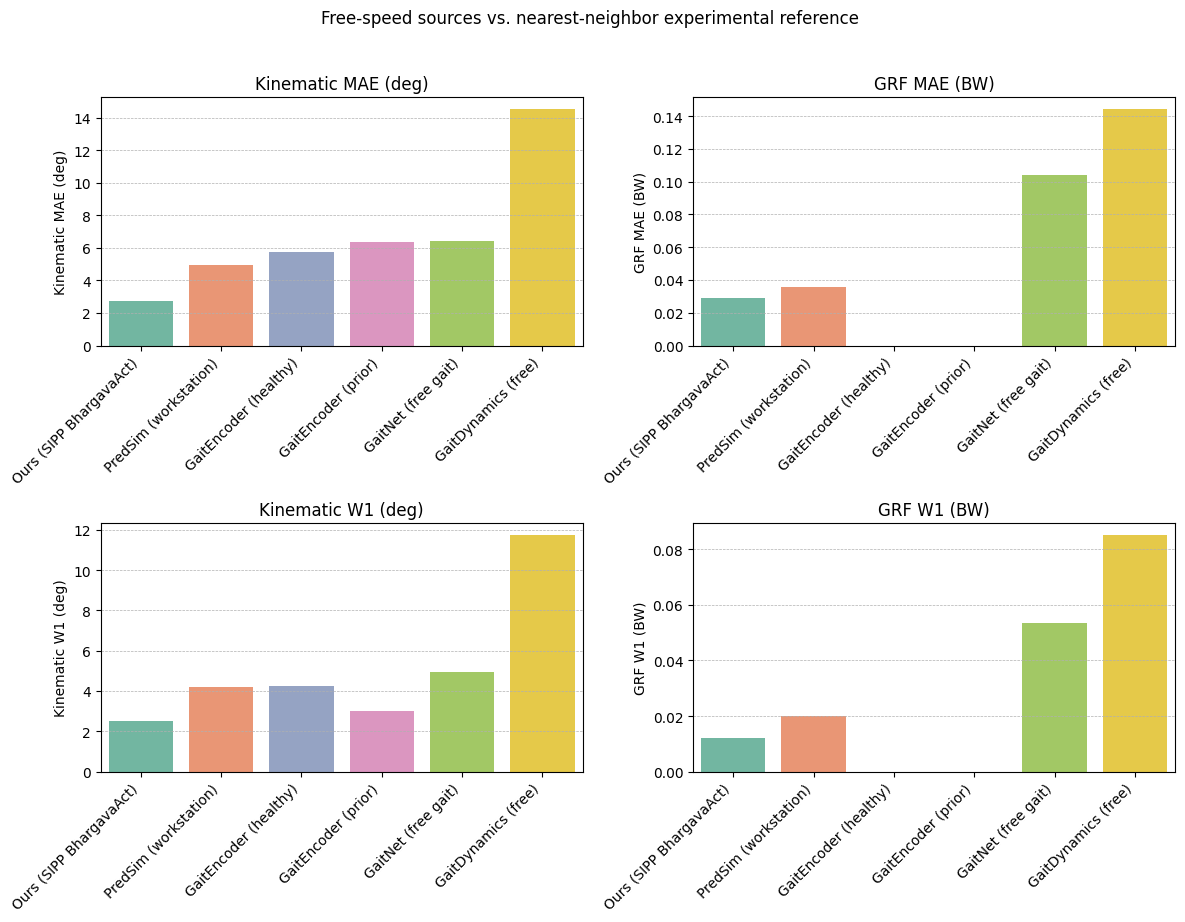

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
metrics = ['Kinematic MAE (deg)', 'GRF MAE (BW)', 'Kinematic W1 (deg)', 'GRF W1 (BW)']
order = summary.sort_values('Kinematic MAE (deg)')['source']
for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=summary, x='source', y=metric, order=order, palette='Set2', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
plt.suptitle('Free-speed sources vs. nearest-neighbor experimental reference', y=1.02)
plt.tight_layout()
plt.show()

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_58422/99949606.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=bench_df, hue='source', x='Kinematic MAE (deg)', palette='Set2', fill=True)


<Axes: xlabel='Kinematic MAE (deg)', ylabel='Density'>

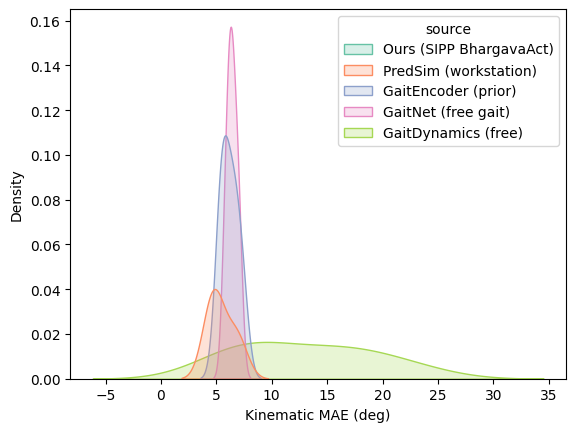

In [14]:
sns.kdeplot(data=bench_df, hue='source', x='Kinematic MAE (deg)', palette='Set2', fill=True)

<Axes: xlabel='_speed', ylabel='Density'>

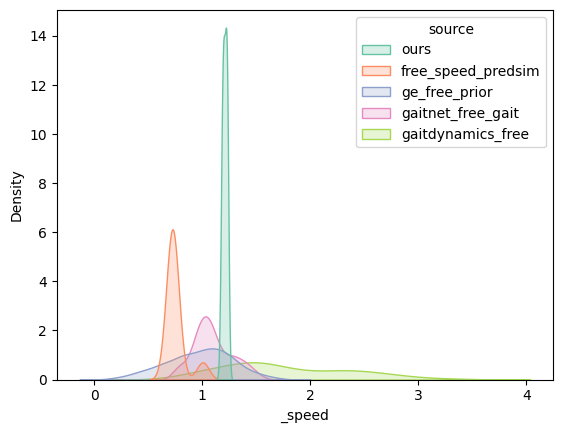

In [15]:
kde_df = pd.concat([d[0] for d in free_sources.values()])
kde_df['_speed'] = np.nansum([kde_df['speed'], kde_df['speed_achieved']], axis=0)
sns.kdeplot(data=kde_df, hue='source', x='_speed', palette='Set2', fill=True, common_norm=False)

In [16]:
kde_df['_speed']

0      1.206172
1      1.227856
2      1.221587
4      1.197560
7      1.188828
         ...   
125    1.515112
126    1.392387
127    1.231311
128    3.050100
129    1.054237
Name: _speed, Length: 1327, dtype: float64

In [17]:
np.nansum([kde_df['speed'], kde_df['speed_achieved']], axis=0) / 2

array([0.60308594, 0.613928  , 0.61079349, ..., 0.61565542, 1.52505002,
       0.52711859])

In [18]:
for key in free_sources.keys():
    print(f"{key}: {len(free_sources[key][0])} trials")

Ours (SIPP BhargavaAct): 7 trials
PredSim (workstation): 10 trials
GaitEncoder (prior): 1000 trials
GaitNet (free gait): 180 trials
GaitDynamics (free): 130 trials
